# Yoneda NN — playground

Rebuilds the article's headline figures **from the verified re-run outputs** in [`data/`](data/)
(no training, seconds on CPU), and re-runs one real experiment live at the end (~1 min).
All numbers were re-verified on 2026-07-22 by fresh runs of the project's own seeded scripts —
see [REVALIDATION.md](REVALIDATION.md). The story behind them: [ARTICLE.md](ARTICLE.md).

<!-- Colab badge goes here once the repo is on GitHub:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/<user>/<repo>/blob/main/playground.ipynb) -->


In [1]:
import json
import matplotlib.pyplot as plt

SURFACE, INK, SECONDARY = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID, BASELINE = "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]

def style(ax):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(True, color=GRID, lw=0.7, alpha=0.8)
    ax.set_axisbelow(True)

def fig_ax(w=7.2, h=4.3):
    fig, ax = plt.subplots(figsize=(w, h), dpi=110)
    fig.patch.set_facecolor(SURFACE)
    style(ax)
    return fig, ax

load = lambda name: json.load(open(f"data/{name}.json"))
rigor_ab, rigor_cd = load("rigor_AB"), load("rigor_CD")
nat, mic = load("nat_kg"), load("microscope_calibration")

## 1. Where the algebra is real, the exact prior wins

Held-out compositional accuracy, 10 seeds, tie-aware Hits@1
([`rigor.py`](research/experiments/kg_compose/rigor.py) §A/§B, re-verified).
The abelian models' failure is structural — commuting composition cannot represent
order-sensitive products; free matrices (RESCAL, ~7× params) can, but crumble at half data.

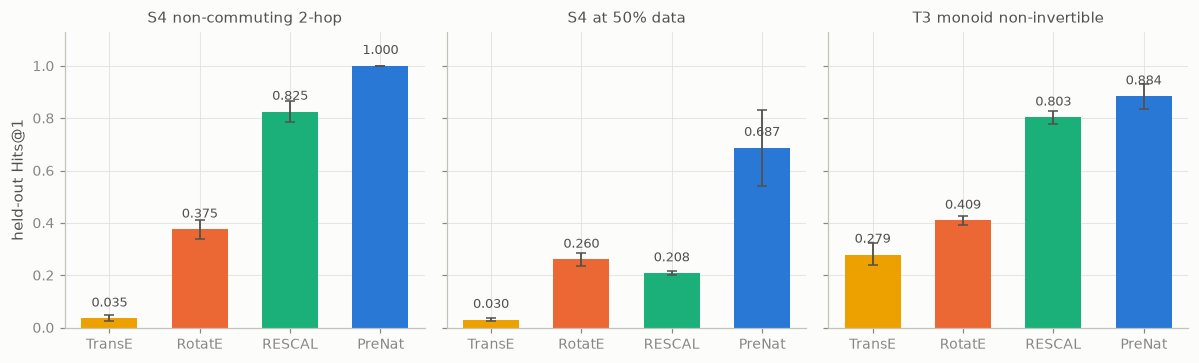

In [2]:
A = rigor_ab["tables"]["A_S4_noncomm_H1"]; B = rigor_ab["tables"]["B_T3_noninv_path_H1"]
MODELS = ["TransE", "RotatE", "RESCAL", "PreNat"]
COL = {"PreNat": BLUE, "RotatE": ORANGE, "RESCAL": AQUA, "TransE": YELLOW}
panels = [("S4 non-commuting 2-hop", {m: A["frac_1.0"][m] for m in MODELS}),
          ("S4 at 50% data", {m: A["frac_0.5"][m] for m in MODELS}),
          ("T3 monoid non-invertible", {m: B[m] for m in MODELS})]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), dpi=110, sharey=True)
fig.patch.set_facecolor(SURFACE)
for ax, (title, vals) in zip(axes, panels):
    style(ax)
    ys = [vals[m]["h1"] for m in MODELS]
    err = [[vals[m]["h1"] - vals[m]["ci"][0] for m in MODELS],
           [vals[m]["ci"][1] - vals[m]["h1"] for m in MODELS]]
    ax.bar(MODELS, ys, color=[COL[m] for m in MODELS], width=0.62,
           yerr=err, ecolor=SECONDARY, capsize=3, error_kw={"lw": 1.2})
    for i, m in enumerate(MODELS):
        ax.annotate(f"{vals[m]['h1']:.3f}", xy=(i, ys[i] + 0.045), ha="center",
                    fontsize=8.5, color=SECONDARY)
    ax.set_title(title, fontsize=10, color=SECONDARY)
    ax.set_ylim(0, 1.13)
axes[0].set_ylabel("held-out Hits@1", fontsize=10, color=SECONDARY)
fig.tight_layout(); plt.show()

## 2. Exactness is earned, not trained

Long-horizon composition on the S4 Cayley graph. The *gradient-learned* model is **not**
drift-free (h=200: 0.14 [0.04, 0.33]) — the guarantee belongs only to the *committed symbolic*
model produced by the discover→identify→commit pipeline
([`discover_compose.py`](research/experiments/kg_compose/discover_compose.py)).

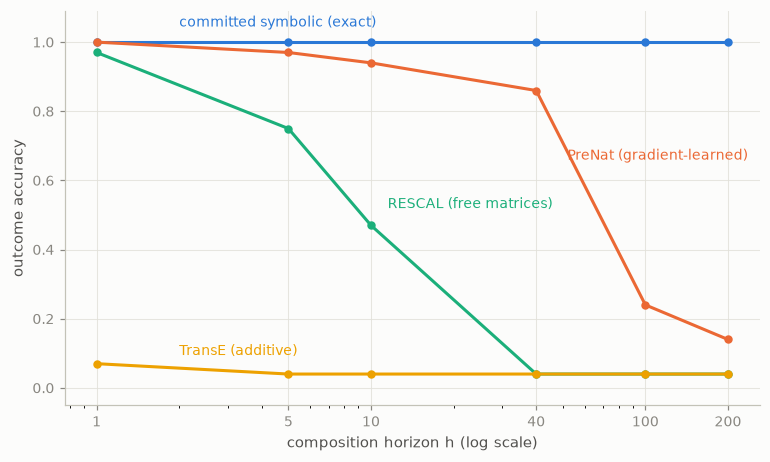

In [3]:
d = rigor_cd["tables"]["C_long_horizon_drift_S4_outcome_accuracy"]; H = d["horizons"]
fig, ax = fig_ax()
for label, key, color in [("committed symbolic (exact)", "SYMBOLIC (exact, by construction)", BLUE),
                          ("PreNat (gradient-learned)", "PreNat (learned)", ORANGE),
                          ("RESCAL (free matrices)", "RESCAL", AQUA),
                          ("TransE (additive)", "TransE", YELLOW)]:
    ax.plot(H, d[key], color=color, lw=2, marker="o", ms=4.5)
for label, x, y, color in [("committed symbolic (exact)", 2.0, 1.045, BLUE),
                           ("PreNat (gradient-learned)", 52, 0.66, ORANGE),
                           ("RESCAL (free matrices)", 11.5, 0.52, AQUA),
                           ("TransE (additive)", 2.0, 0.095, YELLOW)]:
    ax.annotate(label, xy=(x, y), fontsize=9, color=color)
ax.set_xscale("log"); ax.set_xticks(H); ax.set_xticklabels(map(str, H)); ax.set_ylim(-0.05, 1.09)
ax.set_xlabel("composition horizon h (log scale)", fontsize=10, color=SECONDARY)
ax.set_ylabel("outcome accuracy", fontsize=10, color=SECONDARY)
fig.tight_layout(); plt.show()

## 3. The bet itself, retired

Naturality-as-a-loss, given its fairest shot in the flagship setting
([`nat_kg.py`](research/experiments/kg_compose/nat_kg.py)): no significant gain at any data
fraction; the robust variant hurts. The wins came from the algebra, not the naturality signal.

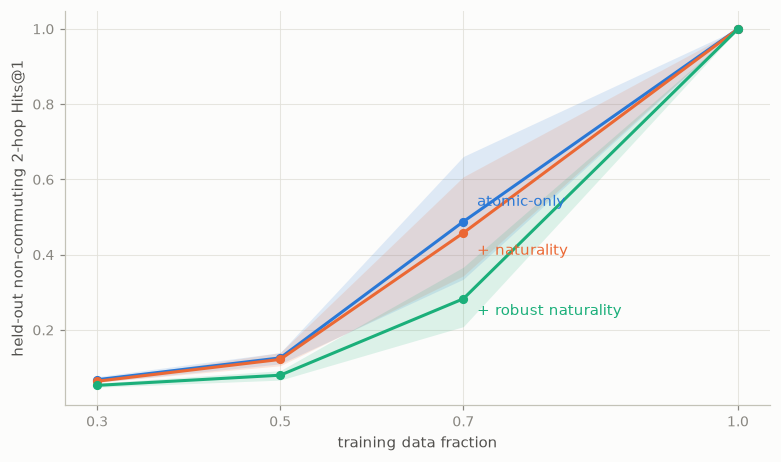

In [4]:
rows = sorted(nat["tables"]["NONCOMM_H@1_by_data_fraction_S4_seeds10"], key=lambda r: r["frac"])
fracs = [r["frac"] for r in rows]
fig, ax = fig_ax()
for label, key, color, ly in [("atomic-only", "atomic_only", BLUE, 0.53),
                              ("+ naturality", "plus_naturality", ORANGE, 0.40),
                              ("+ robust naturality", "plus_robust_naturality", AQUA, 0.24)]:
    ax.plot(fracs, [r[key] for r in rows], color=color, lw=2, marker="o", ms=5)
    ax.fill_between(fracs, [r[f"{key}_ci"][0] for r in rows], [r[f"{key}_ci"][1] for r in rows],
                    color=color, alpha=0.14, lw=0)
    ax.annotate(label, xy=(0.715, ly), fontsize=9.5, color=color)
ax.set_xticks(fracs)
ax.set_xlabel("training data fraction", fontsize=10, color=SECONDARY)
ax.set_ylabel("held-out non-commuting 2-hop Hits@1", fontsize=10, color=SECONDARY)
fig.tight_layout(); plt.show()

## 4. The microscope: measure before you impose

A cheap algebraicity profile predicts the held-out benefit of the exact prior
([`microscope_calibration.py`](research/experiments/kg_compose/microscope_calibration.py)):
Spearman 0.93 [0.80, 0.97], 97% held-out sign prediction. Points colored light→dark by
messiness η; the dashed line is the profile's own decision threshold.

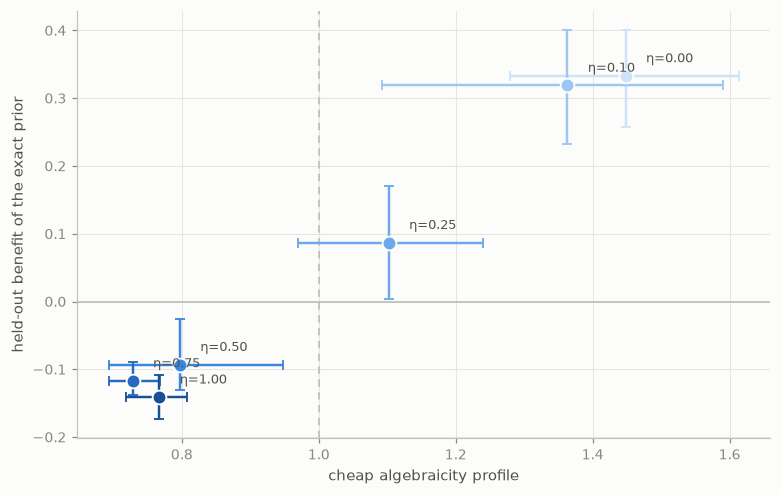

In [5]:
per = mic["tables"]["per_eta"]
fig, ax = fig_ax(7.2, 4.6)
ax.axhline(0, color=BASELINE, lw=1.2); ax.axvline(1.0, color=BASELINE, lw=1.2, ls=(0, (4, 3)))
for i, r in enumerate(per):
    ax.errorbar(r["cheap_algebraicity"], r["prior_benefit_test"],
                xerr=[[r["cheap_algebraicity"] - r["cheap_algebraicity_ci"][0]],
                      [r["cheap_algebraicity_ci"][1] - r["cheap_algebraicity"]]],
                yerr=[[r["prior_benefit_test"] - r["prior_benefit_ci"][0]],
                      [r["prior_benefit_ci"][1] - r["prior_benefit_test"]]],
                fmt="o", ms=9, color=SEQ[i], ecolor=SEQ[i], elinewidth=1.6, capsize=3,
                markeredgecolor="white", markeredgewidth=1.2)
    ax.annotate(f"η={r['eta']:.2f}", xy=(r["cheap_algebraicity"] + 0.03, r["prior_benefit_test"] + 0.02),
                fontsize=8.5, color=SECONDARY)
ax.set_xlabel("cheap algebraicity profile", fontsize=10, color=SECONDARY)
ax.set_ylabel("held-out benefit of the exact prior", fontsize=10, color=SECONDARY)
fig.tight_layout(); plt.show()

## 5. Where it started: the eta-sweep (Runs 1–2)

The pre-registered make-or-break, recomputed live from the on-disk per-seed CSV
([`results.csv`](research/experiments/eta_sweep/results.csv), 3 seeds, pre-rigor):
learned soft naturality beats hard-wiring under functoriality violation — the bet's kill test,
passed. (Its later retirement in the flagship KG setting is §3 above; both are true, in their
own regimes — the article explains the reconciliation.)

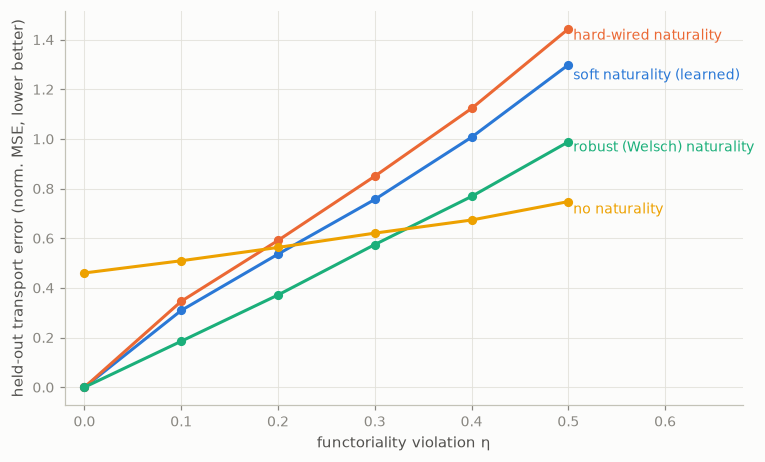

In [6]:
import csv, collections, statistics
d = collections.defaultdict(list)
for row in csv.DictReader(open("research/experiments/eta_sweep/results.csv")):
    d[(float(row["eta"]), row["variant"])].append(float(row["heldout_norm_mse"]))
etas = sorted({k[0] for k in d})
fig, ax = fig_ax()
for label, key, color, ly in [("soft naturality (learned)", "soft", BLUE, 1.24),
                              ("hard-wired naturality", "hard", ORANGE, 1.40),
                              ("robust (Welsch) naturality", "soft-welsch", AQUA, 0.95),
                              ("no naturality", "no-nat", YELLOW, 0.70)]:
    ax.plot(etas, [statistics.mean(d[(e, key)]) for e in etas], color=color, lw=2, marker="o", ms=5)
    ax.annotate(label, xy=(0.505, ly), fontsize=9, color=color)
ax.set_xlim(-0.02, 0.68)
ax.set_xlabel("functoriality violation η", fontsize=10, color=SECONDARY)
ax.set_ylabel("held-out transport error (norm. MSE, lower better)", fontsize=10, color=SECONDARY)
fig.tight_layout(); plt.show()

## 6. Run one for real (~1 min, CPU)

The uniqueness-of-mediator certificate on the hard minting task — unknown apex dimension,
noisy cones. Expected: certificate 1.00 [0.98, 1.00] at every noise level, naive
existence-based minting 0.00, Occam-smallest degrading at σ=0.2.

In [7]:
import sys, subprocess
print(subprocess.run([sys.executable, "research/experiments/kg_compose/limn_hard.py"],
                     capture_output=True, text=True).stdout)

LIMN-HARD: recover an UNKNOWN universal-object dimension from NOISY cones  trials=200

  Product of k in {2,3} factors, random dims; true apex dim D unknown to the method.
  '#fit' = how many candidate apex dims FACTOR the data (existence is ambiguous: a whole
  range [D..] fits). Accuracy = recovers the true D exactly (Wilson 95% CI).

  sigma  | #fit (ambiguity) |  EXISTENCE-naive   |  Occam-smallest  |   CERTIFICATE    |  OOD-ok 
  --------------------------------------------------------------------------------------------
  0.00  |       4.00       |  0.00 [0.00,0.02]  | 1.00 [0.98,1.00] | 1.00 [0.98,1.00] |   100%  
  0.05  |       4.00       |  0.00 [0.00,0.02]  | 1.00 [0.98,1.00] | 1.00 [0.98,1.00] |   100%  
  0.10  |       4.00       |  0.00 [0.00,0.02]  | 1.00 [0.98,1.00] | 1.00 [0.98,1.00] |   100%  
  0.20  |       4.39       |  0.00 [0.00,0.02]  | 0.61 [0.54,0.67] | 1.00 [0.98,1.00] |   100%  

  READING: EXISTENCE is ambiguous (#fit > 1: many over-complete apexes factor t